## Redefine model to accept forecast as a parameter and only train one model

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import rpy2.robjects as robjects

folder_name = '3_state_model'

data_log = pd.read_csv(folder_name + "/close_data_log.csv")

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']

hmm_stats_r = readRDS(folder_name + "/hmm_stats_df.rds")
hmm_stats_df = r_to_df(hmm_stats_r)

hmm_state_losses = np.array(readRDS(folder_name + "/hmm_state_losses.rds"))
hmm_predictions = np.array(readRDS(folder_name + "/hmm_predictions.rds"))
hmm_ground_truth = np.array(readRDS(folder_name + "/hmm_ground_truth.rds"))

X_train = np.array(readRDS(folder_name + "/lstm_X_train.rds"))
Y_train = np.array(readRDS(folder_name + "/lstm_Y_train.rds"))
X_valid = np.array(readRDS(folder_name + "/lstm_X_valid.rds"))
Y_valid = np.array(readRDS(folder_name + "/lstm_Y_valid.rds"))
X_test = np.array(readRDS(folder_name + "/lstm_X_test.rds"))
Y_test = np.array(readRDS(folder_name + "/lstm_Y_test.rds"))

n_states = Y_train.shape[2]

In [3]:
X_train.shape, Y_train.shape, X_valid.shape, Y_valid.shape, X_test.shape, Y_test.shape

((672, 10, 20),
 (672, 10, 3),
 (234, 10, 20),
 (234, 10, 3),
 (309, 10, 20),
 (309, 10, 3))

In [4]:
forecast_horizon = Y_train.shape[1]

# Create a function to prepare data for all splits
def prepare_data_with_horizon(X, Y, shuffle=True):

    # Create one-hot encoded horizon inputs
    horizon_input = np.eye(forecast_horizon)
    horizon_input = np.repeat(horizon_input, X.shape[0], axis=0)

    # Repeat X for each forecast horizon
    X = np.concatenate([X for i in range(forecast_horizon)], axis=0)
    # Get Y for each forecast horizon
    Y = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    
    # Shuffle the rows of X, horizon_input, and Y in the same order using numpy
    if shuffle:
        idx = np.random.permutation(X.shape[0])
        X = X[idx]
        horizon_input = horizon_input[idx]
        Y = Y[idx]
    return X, horizon_input, Y

# Prepare validation and test data
X_train_full, horizon_train_full, Y_train_full = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_full, horizon_valid_full, Y_valid_full = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_full, horizon_test_full, Y_test_full = prepare_data_with_horizon(X_test, Y_test, shuffle=False)

In [5]:
print(X_train_full.shape, horizon_train_full.shape, Y_train_full.shape)
print(X_valid_full.shape, horizon_valid_full.shape, Y_valid_full.shape)
print(X_test_full.shape, horizon_test_full.shape, Y_test_full.shape)

(6720, 10, 20) (6720, 10) (6720, 3)
(2340, 10, 20) (2340, 10) (2340, 3)
(3090, 10, 20) (3090, 10) (3090, 3)


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence

# Assuming X_train, Y_train, X_valid, Y_valid, and n_states are defined elsewhere
# lookback and forecast_horizon are provided but not directly used in model building

# Compute Dirichlet parameters and predicted probabilities (for reference, not used in model)
def dirichlet_layer(evidence):
    alpha = evidence + 1
    S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
    probs = alpha / S
    return probs, alpha, S

# Custom evidential loss with annealing
class EvidentialLoss(tf.keras.losses.Loss):
    def __init__(self, annealing_rate=100.0, name='evidential_loss'):
        super().__init__(name=name)
        self.annealing_rate = tf.constant(annealing_rate, dtype=tf.float32)
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)
    
    def call(self, y_true, evidence):
        alpha = evidence + 1
        S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
        probs = alpha / S

        # Classification error: categorical cross-entropy for soft probability targets
        err = tf.keras.losses.categorical_crossentropy(y_true, probs)

        var = tf.reduce_sum(probs * (1 - probs) / (S + 1), axis=-1, keepdims=True)
        
        # Annealing factor for the regularization term
        lambda_ = tf.minimum(1.0, self.current_epoch / self.annealing_rate)

        return tf.reduce_mean(err + lambda_ * var, axis=-1)

# Custom callback to update the current epoch in the loss instance
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model, 'loss') and isinstance(self.model.loss, EvidentialLoss):
            self.model.loss.current_epoch.assign(tf.cast(epoch, tf.float32))

# Custom metric using KL divergence
def evidential_kl_divergence(y_true, y_pred):
    probs, _, _ = dirichlet_layer(y_pred)  # Derive probabilities from evidence
    return kullback_leibler_divergence(y_true, probs)

2026-03-03 10:19:47.656270: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 10:19:58.569180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772561999.376358 1448022 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772561999.764628 1448022 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772562001.660921 1448022 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Test with a single parameter config

In [7]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Concatenate
import time  # For timing the training

tf.keras.backend.clear_session()

dirichlet_output = True

# Define fixed hyperparameters
lookback = 10
include_tsx = True
include_crude = True
include_gold = True
include_copper = True
include_sp500 = True

rnn_units = 16
dense_units = 8
dropout_rate = 0.3
embedding_dim = 4

# Build feature mask based on fixed inclusions
feature_mask_list = (
    [1.0] * 4 if include_tsx else [0.0] * 4
) + (
    [1.0] * 4 if include_crude else [0.0] * 4
) + (
    [1.0] * 4 if include_gold else [0.0] * 4
) + (
    [1.0] * 4 if include_copper else [0.0] * 4
) + (
    [1.0] * 4 if include_sp500 else [0.0] * 4
)
feature_mask = tf.constant(feature_mask_list, dtype=tf.float32)

# Primary input for timeseries data (adjust shape if X_train changes)
timeseries_input = layers.Input(shape=X_train_full.shape[1:])

# Auxiliary input for one-hot encoded horizon (length 10)
horizon_input = layers.Input(shape=(10,))

# Embed the horizon input into a dense representation
horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

# Lambda layer to slice to the last 'lookback' timesteps
sliced = layers.Lambda(
    lambda x: x[:, -lookback:, :],
    output_shape=(lookback, timeseries_input.shape[-1])
)(timeseries_input)

# Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
masked = layers.Lambda(
    lambda x: x * tf.reshape(feature_mask, (1, 1, 20)),
    output_shape=(lookback, 20)
    )(sliced)

# RNN layer with added dropout
rnn_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate)(masked)

# Concatenate RNN output with embedded horizon
concat = Concatenate()([rnn_out, horizon_embed])

# Dense layers following concatenation
dense1 = layers.Dense(dense_units, activation='relu')(concat)
drop1 = layers.Dropout(dropout_rate)(dense1)
dense2 = layers.Dense(dense_units, activation='relu')(drop1)
drop2 = layers.Dropout(dropout_rate)(dense2)

# Output raw evidence (non-negative)
if dirichlet_output:
    output = layers.Dense(n_states, activation='softplus')(drop2)
else:
    output = layers.Dense(n_states, activation='softmax')(drop2)

# Define the multi-input model
model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

if dirichlet_output:
    model.compile(
        loss=EvidentialLoss(annealing_rate=60.0),
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy', evidential_kl_divergence]  # Accuracy on argmax(probs)
    )
else:
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']  # Accuracy on argmax(probs)
    )

I0000 00:00:1772562124.592627 1448022 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8074 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3 MIG 1g.10gb, pci bus id: 0000:46:00.0, compute capability: 9.0


In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 20)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 20)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 16)        │        592 │ lambda_1[0][0]    │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         44 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20)        │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        168 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │         72 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         27 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 903 (3.53 KB)

 Trainable params: 903 (3.53 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import os
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# # Optional GPU/thread settings if applicable
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# tf.config.threading.set_intra_op_parallelism_threads(1)
# tf.config.threading.set_inter_op_parallelism_threads(1)

if dirichlet_output:
    history = model.fit(
        [X_train_full, horizon_train_full], Y_train_full,
        validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
        callbacks=[AnnealingCallback()],
        epochs=100,  # Use the same number as in your tuner setup
        verbose=1  # Set to 0 for silent output if preferred
    )
else:
    history = model.fit(
        [X_train_full, horizon_train_full], Y_train_full,
        validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
        callbacks=[early_stopping],
        epochs=100,  # Use the same number as in your tuner setup
        verbose=1  # Set to 0 for silent output if preferred
    )


Epoch 1/100


I0000 00:00:1772562146.275970 1452395 service.cc:152] XLA service 0x14f188022a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772562146.276669 1452395 service.cc:160]   StreamExecutor device (0): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
2026-03-03 10:22:28.520825: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772562150.812818 1452395 cuda_dnn.cc:529] Loaded cuDNN version 91000
2026-03-03 10:22:34.593187: W external/local_xla/xla/stream_executor/gpu/redzone_allocator_kernel_cuda.cc:135] NOT_FOUND: Couldn't find a suitable version of ptxas. The following locations were considered: bin/ptxas, /project/rrg-kmsmith/dcs01/forecast_research/finance/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.12.4/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/so

 73/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4116 - evidential_kl_divergence: 0.7176 - loss: 1.0775 

I0000 00:00:1772562156.485073 1452395 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


210/210 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4372 - evidential_kl_divergence: 0.7095 - loss: 1.0689 - val_accuracy: 0.3248 - val_evidential_kl_divergence: 0.7012 - val_loss: 1.0425
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4506 - evidential_kl_divergence: 0.6942 - loss: 1.0556 - val_accuracy: 0.5158 - val_evidential_kl_divergence: 0.6747 - val_loss: 1.0179
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4622 - evidential_kl_divergence: 0.6772 - loss: 1.0404 - val_accuracy: 0.7235 - val_evidential_kl_divergence: 0.6439 - val_loss: 0.9890
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4601 - evidential_kl_divergence: 0.6582 - loss: 1.0232 - val_accuracy: 0.7299 - val_evidential_kl_divergence: 0.6016 - val_loss: 0.9485
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4708 - evidential_kl_divergence: 0.6373 - loss: 1.0038 - val_accuracy: 0.7444 - val_evidential_kl_divergence: 0.5641 - val_loss: 0.

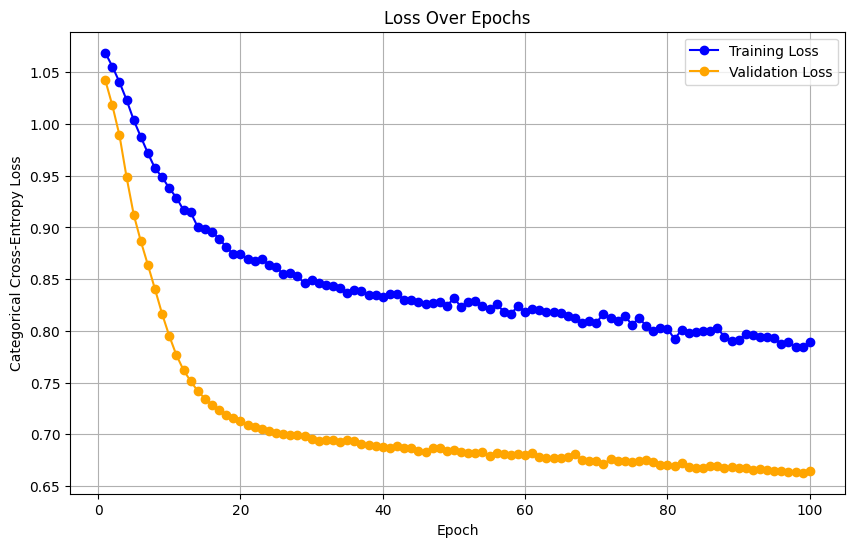

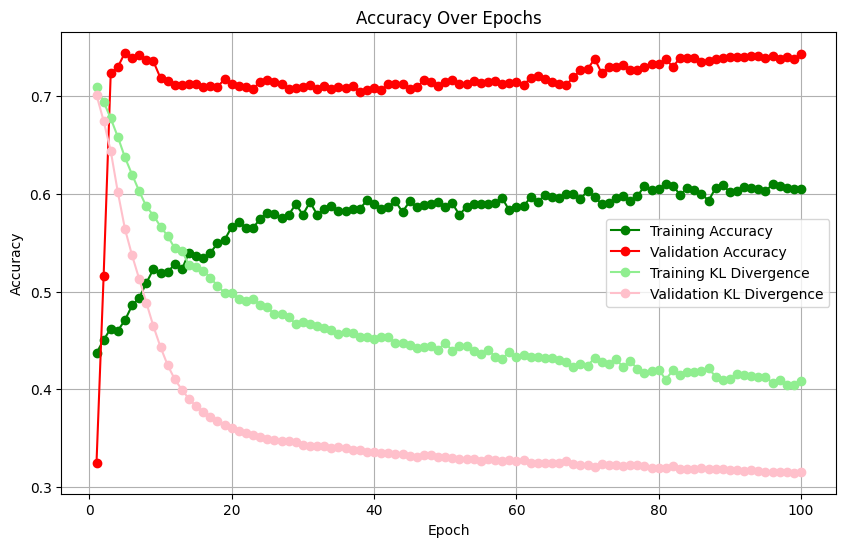

In [10]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', marker='o', color='green')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='red')
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

In [11]:
test_predictions = model.predict([X_test_full, horizon_test_full])
if dirichlet_output:
    probs, alpha, S = dirichlet_layer(test_predictions)
    probs = probs.numpy()
else:
    probs = test_predictions
probs_reshaped = probs.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
loss = -np.sum(Y_test_full * np.log(np.clip(probs, 1e-15, 1.0)), axis=1)

loss_reshaped = loss.reshape(forecast_horizon, -1).T
stats = {
    'mean': np.nanmean(loss_reshaped, axis=0),
    'median': np.nanmedian(loss_reshaped, axis=0),
    'P25': np.nanpercentile(loss_reshaped, 25, axis=0),
    'P75': np.nanpercentile(loss_reshaped, 75, axis=0),
    'max': np.nanmax(loss_reshaped, axis=0),
    'min': np.nanmin(loss_reshaped, axis=0)
}

# Convert to DataFrame for better display
lstm_stats_df = pd.DataFrame(stats)
lstm_stats_df

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,mean,median,P25,P75,max,min
0,0.772203,0.695288,0.554230,0.840466,4.247035,0.259601
1,0.802213,0.702754,0.562451,0.853685,4.419303,0.277531
2,0.827490,0.716359,0.576641,0.878396,4.708638,0.371621
3,0.850168,0.717312,0.582909,0.880053,4.741466,0.508230
4,0.867230,0.716137,0.590641,0.878195,4.767128,0.507198
5,0.889305,0.725920,0.591569,0.886319,4.718981,0.508972
6,0.902304,0.722874,0.598630,0.886253,4.753263,0.509347
7,0.910478,0.727355,0.604691,0.889117,4.729074,0.510425
8,0.909230,0.723973,0.608333,0.888843,4.757771,0.509272
9,0.907508,0.717277,0.608180,0.878155,4.792048,0.509549


In [12]:
# Get the most likely state (argmax) for each probability vector
argmax_states = np.argmax(probs_reshaped, axis=2)
# Get value counts of the most likely states across all samples and horizons
state_counts = pd.Series(argmax_states.flatten()).value_counts()
state_counts

2    2529
1     402
0     159
Name: count, dtype: int64

In [13]:
pd.Series(np.argmax(Y_test_full, axis=1).flatten()).value_counts()

2    1970
1    1020
0     100
Name: count, dtype: int64

In [14]:
probs_reshaped[24, :, :]

array([[0.7528002 , 0.14146726, 0.10573252],
       [0.7641309 , 0.13379055, 0.10207856],
       [0.75040746, 0.14309265, 0.1064999 ],
       [0.7545602 , 0.14027244, 0.10516744],
       [0.7452906 , 0.14657274, 0.10813674],
       [0.75691265, 0.13867633, 0.10441102],
       [0.75555557, 0.13959698, 0.10484749],
       [0.75555557, 0.13959698, 0.10484749],
       [0.7484621 , 0.1444151 , 0.10712281],
       [0.7482006 , 0.14459299, 0.10720649]], dtype=float32)

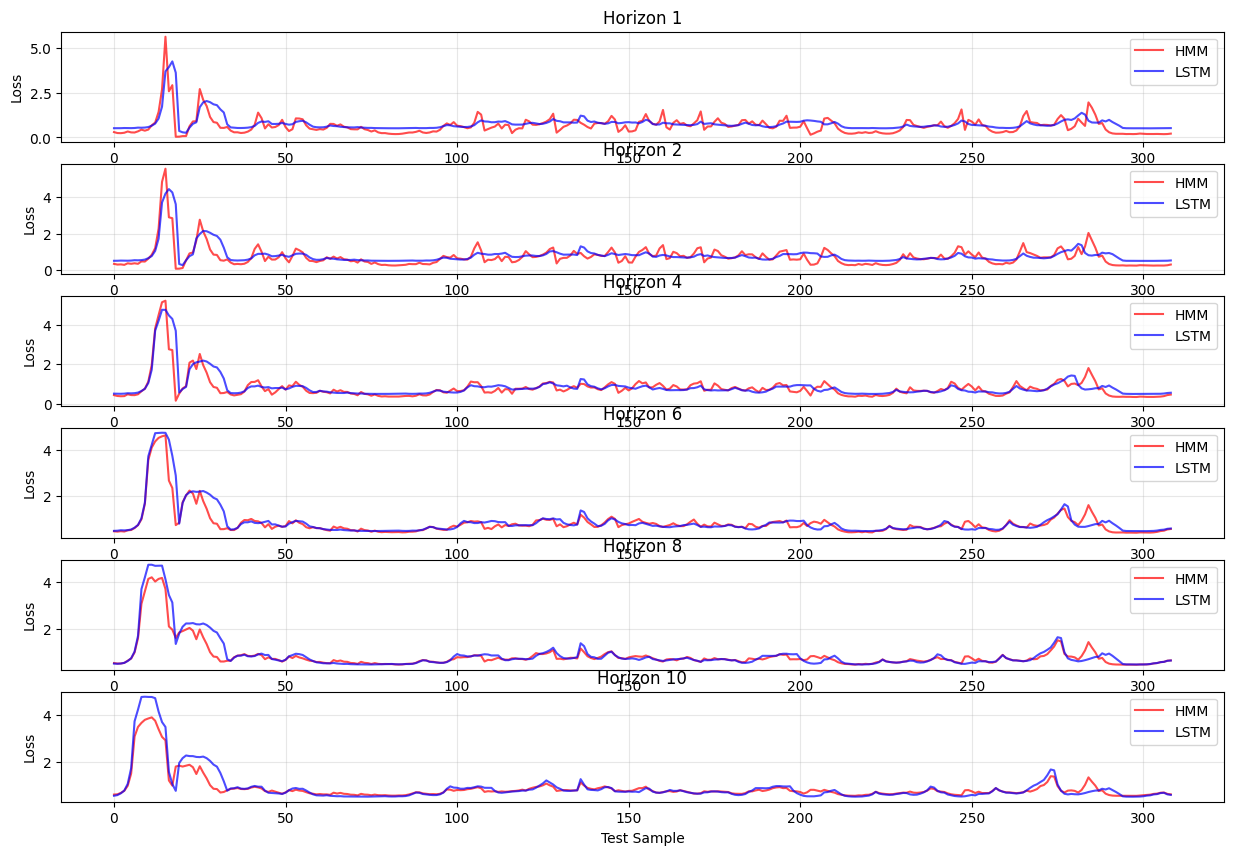

In [15]:
# Horizon indices (0-based): 0, 1, 3
horizons = [0, 1, 3, 5, 7, 9]
titles = ['Horizon 1', 'Horizon 2', 'Horizon 4', 'Horizon 6', 'Horizon 8', 'Horizon 10']

plt.figure(figsize=(15, 10))

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='red', alpha=0.7)
    ax.plot(loss_reshaped[:, horizon], label='LSTM', color='blue', alpha=0.7)
    ax.set_title(titles[i])
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

## Run hypertuning

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Concatenate

# Model-building function for hyperparameter tuning
def build_model(hp):
    
    # Tune lookback (history length/timesteps)
    lookback = hp.Choice('lookback', values=[5, 10])
    
    # Tune feature inclusion (one boolean per group of 4 columns)
    include_tsx = True
    include_crude = hp.Boolean('include_Crude_Oil_Futures', default=True)
    include_gold = hp.Boolean('include_Gold_Futures', default=True)
    include_copper = hp.Boolean('include_Copper_Futures', default=True)
    include_sp500 = hp.Boolean('include_SP_500', default=True)
    
    # Build feature mask: 1.0 for included groups, 0.0 for excluded
    feature_mask_list = (
        [1.0] * 4 if include_tsx else [0.0] * 4
    ) + (
        [1.0] * 4 if include_crude else [0.0] * 4
    ) + (
        [1.0] * 4 if include_gold else [0.0] * 4
    ) + (
        [1.0] * 4 if include_copper else [0.0] * 4
    ) + (
        [1.0] * 4 if include_sp500 else [0.0] * 4
    )
    feature_mask = tf.constant(feature_mask_list, dtype=tf.float32)
    
    # Other hyperparameters (unchanged)
    lstm_units = hp.Choice('lstm_units', values=[4, 8, 16, 32])
    dense_units = hp.Choice('dense_units', values=[4, 8, 16, 32])
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.4, step=0.1)
    # Tune embedding dimension for horizon input
    embedding_dim = hp.Choice('embedding_dim', values=[4])
    #learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3])
    #annealing_rate = hp.Choice('annealing_rate', values=[30.0, 60.0, 90.0, 120.0])

    # Primary input for timeseries data
    timeseries_input = layers.Input(shape=X_train_full.shape[1:])
    
    # Auxiliary input for one-hot encoded horizon (length 10)
    horizon_input = layers.Input(shape=(10,))
    
    # Embed the horizon input into a dense representation
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)
    
    # Lambda layer to slice to the last 'lookback' timesteps
    sliced = layers.Lambda(lambda x: x[:, -lookback:, :])(timeseries_input)
    
    # Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
    masked = layers.Lambda(lambda x: x * tf.reshape(feature_mask, (1, 1, 20)))(sliced)
    
    # LSTM layer with added dropout
    lstm_out = layers.SimpleRNN(lstm_units, dropout=dropout_rate)(masked)
    
    # Concatenate LSTM output with embedded horizon
    concat = Concatenate()([lstm_out, horizon_embed])
    
    # Dense layers following concatenation
    dense1 = layers.Dense(dense_units, activation='relu')(concat)
    drop1 = layers.Dropout(dropout_rate)(dense1)
    dense2 = layers.Dense(dense_units, activation='relu')(drop1)
    drop2 = layers.Dropout(dropout_rate)(dense2)
    
    # Output raw evidence (non-negative)
    output = layers.Dense(n_states, activation='softplus')(drop2)
    
    # Define the multi-input model
    model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)
    
    model.compile(
        loss=EvidentialLoss(annealing_rate=100.0),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        metrics=[evidential_kl_divergence]  # Accuracy on argmax(probs)
    )
    
    return model

In [17]:
tf.keras.backend.clear_session()
# Initialize the tuner (using Hyperband for efficiency)
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective(name='val_evidential_kl_divergence', direction='min'), 
    max_epochs=80,
    factor=3,
    directory='tuner_dir',
    project_name='evidential_lstm_tuning_v3',
    seed=42
)

# Define callbacks: annealing and early stopping
annealing_callback = AnnealingCallback()
#early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform the hyperparameter search
tuner.search(
    [X_train_full, horizon_train_full], 
    Y_train_full, 
    epochs=80, 
    validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
    callbacks=[annealing_callback],
    verbose=1  # Adjust verbosity as needed
)

# Retrieve the best model and hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=3)[0]

# Optionally, print the best hyperparameters
print(best_hyperparameters.values)

# Summary of the best model
best_model.summary()

Trial 90 Complete [00h 01m 01s]
val_evidential_kl_divergence: 0.5413687825202942

Best val_evidential_kl_divergence So Far: 0.28674784302711487
Total elapsed time: 00h 24m 28s
{'lookback': 10, 'include_Crude_Oil_Futures': False, 'include_Gold_Futures': True, 'include_Copper_Futures': True, 'include_SP_500': False, 'lstm_units': 8, 'dense_units': 32, 'dropout_rate': 0.2, 'embedding_dim': 4, 'tuner/epochs': 80, 'tuner/initial_epoch': 27, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0047'}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 20)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 20)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        232 │ lambda_1[0][0]    │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         44 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12)        │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,847 (7.21 KB)

 Trainable params: 1,847 (7.21 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
tuner.get_best_hyperparameters(num_trials=2)[1].values

{'lookback': 5,
 'include_Crude_Oil_Futures': False,
 'include_Gold_Futures': False,
 'include_Copper_Futures': False,
 'include_SP_500': False,
 'lstm_units': 8,
 'dense_units': 32,
 'dropout_rate': 0.30000000000000004,
 'embedding_dim': 4,
 'tuner/epochs': 80,
 'tuner/initial_epoch': 27,
 'tuner/bracket': 3,
 'tuner/round': 3,
 'tuner/trial_id': '0048'}

In [22]:
import pandas as pd

# Retrieve the top 10 trials from the tuner's oracle, sorted by the objective (lowest val_evidential_kl_divergence)
best_trials = tuner.oracle.get_best_trials(num_trials=20)

# Prepare a list to hold the data for the DataFrame
data = []

# Iterate over each trial to extract hyperparameters and score
for trial in best_trials:
    # Copy the hyperparameter values as a dictionary
    hp_values = trial.hyperparameters.values.copy()
    # Add the score (val_evidential_kl_divergence) to the dictionary
    hp_values['val_evidential_kl_divergence'] = trial.score
    # Append to the list
    data.append(hp_values)

# Create the DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Optionally, sort or reorder columns if needed (e.g., move score to the front)
df = df[['val_evidential_kl_divergence'] + [col for col in df.columns if col != 'val_evidential_kl_divergence']]

# Display or save the DataFrame
df

,val_evidential_kl_divergence,lookback,include_Crude_Oil_Futures,include_Gold_Futures,include_Copper_Futures,include_SP_500,lstm_units,dense_units,dropout_rate,embedding_dim,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,tuner/trial_id
0,0.286748,10,False,True,True,False,8,32,0.2,4,80,27,3,3,0047
1,0.303928,5,False,False,False,False,8,32,0.3,4,80,27,3,3,0048
2,0.306535,10,False,True,True,False,8,32,0.2,4,27,9,3,2,0045
3,0.308965,5,True,False,True,False,32,16,0.3,4,80,27,1,1,0079
4,0.310135,5,False,True,False,True,8,32,0.2,4,80,27,2,2,0069
5,0.313104,10,False,False,False,False,4,32,0.4,4,80,27,1,1,0076
6,0.319003,10,True,False,True,False,16,16,0.1,4,80,27,2,2,0067
7,0.320596,10,False,True,True,False,8,4,0.1,4,80,0,0,0,NaN
8,0.324317,5,False,True,False,True,8,32,0.2,4,27,9,2,1,0059
9,0.324582,5,False,False,False,False,8,32,0.3,4,27,9,3,2,0038


In [20]:
import pandas as pd
from scipy.stats import f_oneway, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Section 1: Extract Trial Data from Tuner
# Access trials from the tuner's oracle and compile into a DataFrame
trials = tuner.oracle.trials.values()
trial_data = []
for trial in trials:
    hps = trial.hyperparameters.values  # Dictionary of hyperparameters
    score = trial.score  # Objective value (e.g., val_loss or val_accuracy)
    trial_data.append({**hps, 'score': score})

df = pd.DataFrame(trial_data)
df.drop(columns=['tuner/epochs', 'tuner/initial_epoch', 'tuner/bracket', 'tuner/round', 'tuner/trial_id'], inplace=True, errors='ignore')
print(f"Extracted {len(df)} trials for analysis.")

# Section 2: Statistical Tests for Individual Sensitivity
# For discrete/categorical hyperparameters (e.g., 'lookback', 'lstm_units', booleans)
discrete_params = ['lookback', 'lstm_units', 'dense_units', 'embedding_dim',
                   'include_TSX_Composite', 'include_Crude_Oil_Futures',
                   'include_Gold_Futures', 'include_Copper_Futures', 'include_SP_500']

for param in discrete_params:
    unique_values = df[param].unique()
    if len(unique_values) > 1:
        groups = [df[df[param] == val]['score'] for val in unique_values]
        f_stat, p_value = f_oneway(*groups)
        print(f"ANOVA for {param}: F-statistic={f_stat:.2f}, p-value={p_value:.4f}")
        # Interpretation: p-value < 0.05 indicates high sensitivity
    else:
        print(f"{param} has insufficient variation for ANOVA.")

# For continuous hyperparameters (e.g., 'dropout_rate')
continuous_params = ['dropout_rate']
for param in continuous_params:
    corr, p_value = spearmanr(df[param], df['score'])
    print(f"Spearman correlation for {param}: correlation={corr:.2f}, p-value={p_value:.4f}")
    # Interpretation: |correlation| > 0.3 with p-value < 0.05 indicates sensitivity

# Section 3: Surrogate Model for Global Importances and Partial Dependence
# Preprocess: Encode categorical/boolean columns
df_encoded = df.copy()
for col in df_encoded.columns.drop('score'):
    if df_encoded[col].dtype in ['object', 'bool']:
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop('score', axis=1)
y = df_encoded['score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Extract and display feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nHyperparameter Importances (higher values indicate greater sensitivity):")
print(importances)

# Visualize importances
importances.plot(kind='bar')
plt.title('Hyperparameter Importances from Random Forest')
plt.xlabel('Hyperparameters')
plt.ylabel('Importance Score')
plt.show()

# Partial Dependence Plots for selected hyperparameters (e.g., top sensitive ones)
selected_params = importances.index[:3].tolist()  # Top 3 for example
PartialDependenceDisplay.from_estimator(rf, X_train, features=selected_params)
plt.suptitle('Partial Dependence Plots')
plt.show()

Extracted 90 trials for analysis.
ANOVA for lookback: F-statistic=2.21, p-value=0.1403
ANOVA for lstm_units: F-statistic=2.06, p-value=0.1115
ANOVA for dense_units: F-statistic=15.69, p-value=0.0000
embedding_dim has insufficient variation for ANOVA.


KeyError: 'include_TSX_Composite'

In [ ]:
model = best_model
test_predictions = model.predict([X_test_full, horizon_test_full])
if dirichlet_output:
    probs, alpha, S = dirichlet_layer(test_predictions)
    probs = probs.numpy()
else:
    probs = test_predictions
probs_reshaped = probs.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
loss = -np.sum(Y_test_full * np.log(np.clip(probs, 1e-15, 1.0)), axis=1)

loss_reshaped = loss.reshape(forecast_horizon, -1).T
stats = {
    'mean': np.nanmean(loss_reshaped, axis=0),
    'median': np.nanmedian(loss_reshaped, axis=0),
    'P25': np.nanpercentile(loss_reshaped, 25, axis=0),
    'P75': np.nanpercentile(loss_reshaped, 75, axis=0),
    'max': np.nanmax(loss_reshaped, axis=0),
    'min': np.nanmin(loss_reshaped, axis=0)
}

# Convert to DataFrame for better display
lstm_stats_df = pd.DataFrame(stats)
lstm_stats_df

2026-02-02 18:54:14.021088: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


,mean,median,P25,P75,max,min
0,0.833566,0.690695,0.513571,0.933923,4.263104,0.335561
1,0.849081,0.696787,0.517775,0.945636,4.302840,0.337359
2,0.860465,0.699039,0.523266,0.944549,4.464251,0.342928
3,0.869003,0.696779,0.529360,0.948241,4.489412,0.339446
4,0.877136,0.696243,0.541869,0.954987,4.520152,0.337786
5,0.884197,0.691876,0.562023,0.955060,4.548947,0.336569
6,0.888715,0.690455,0.557681,0.956993,4.564534,0.338474
7,0.886612,0.694964,0.564238,0.957738,4.582941,0.337215
8,0.884075,0.701813,0.566939,0.943358,4.588792,0.337992
9,0.878891,0.701987,0.568961,0.938848,4.594351,0.336855


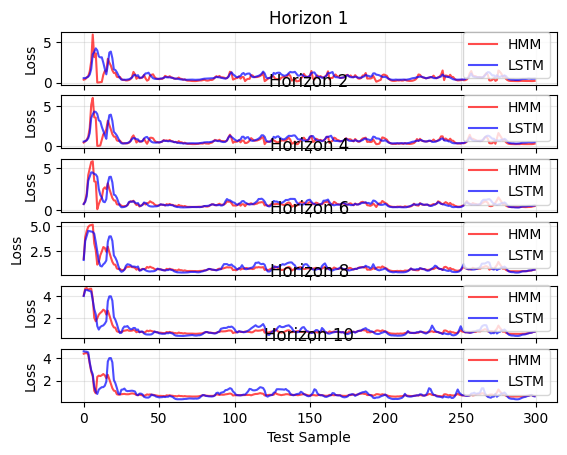

In [ ]:
# Horizon indices (0-based): 0, 1, 3
horizons = [0, 1, 3, 5, 7, 9]
titles = ['Horizon 1', 'Horizon 2', 'Horizon 4', 'Horizon 6', 'Horizon 8', 'Horizon 10']

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='red', alpha=0.7)
    ax.plot(loss_reshaped[:, horizon], label='LSTM', color='blue', alpha=0.7)
    ax.set_title(titles[i])
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)


In [ ]:
# Get the best hyperparameters which includes the number of epochs trained
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
epochs_trained = best_hp.get('tuner/epochs')
print(f"Number of epochs used to train the best model: {epochs_trained}")

# You can also see the full training configuration
print(f"\nBest model configuration:")
print(f"Trial ID: {best_hp.get('tuner/trial_id')}")
print(f"Epochs: {epochs_trained}")
print(f"Bracket: {best_hp.get('tuner/bracket')}")
print(f"Round: {best_hp.get('tuner/round')}")


Number of epochs used to train the best model: 75

Best model configuration:
Trial ID: 0046
Epochs: 75
Bracket: 3
Round: 3
